#**Preprocessing**

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
data1 = pd.read_csv("/content/dataset_TSMC2014_TKY.csv")
data1.head()

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,1541,4f0fd5a8e4b03856eeb6c8cb,4bf58dd8d48988d10c951735,Cosmetics Shop,35.705101,139.619590,540.0,Tue Apr 03 18:17:18 +0000 2012
1,868,4b7b884ff964a5207d662fe3,4bf58dd8d48988d1d1941735,Ramen / Noodle House,35.715581,139.800317,540.0,Tue Apr 03 18:22:04 +0000 2012
2,114,4c16fdda96040f477cc473a5,4d954b0ea243a5684a65b473,Convenience Store,35.714542,139.480065,540.0,Tue Apr 03 19:12:07 +0000 2012
3,868,4c178638c2dfc928651ea869,4bf58dd8d48988d118951735,Food & Drink Shop,35.725592,139.776633,540.0,Tue Apr 03 19:12:13 +0000 2012
4,1458,4f568309e4b071452e447afe,4f2a210c4b9023bd5841ed28,Housing Development,35.656083,139.734046,540.0,Tue Apr 03 19:18:23 +0000 2012


In [35]:
data2 = pd.read_csv("/content/dataset_TSMC2014_NYC.csv")
data2.head()

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240.0,Tue Apr 03 18:00:09 +0000 2012
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240.0,Tue Apr 03 18:00:25 +0000 2012
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240.0,Tue Apr 03 18:02:24 +0000 2012
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240.0,Tue Apr 03 18:02:41 +0000 2012
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240.0,Tue Apr 03 18:03:00 +0000 2012


In [28]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57700 entries, 0 to 57699
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   userId           57700 non-null  int64  
 1   venueId          57699 non-null  object 
 2   venueCategoryId  57699 non-null  object 
 3   venueCategory    57699 non-null  object 
 4   latitude         57699 non-null  float64
 5   longitude        57699 non-null  float64
 6   timezoneOffset   57699 non-null  float64
 7   utcTimestamp     57699 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 3.5+ MB


In [39]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57008 entries, 0 to 57007
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   userId           57008 non-null  int64  
 1   venueId          57008 non-null  object 
 2   venueCategoryId  57007 non-null  object 
 3   venueCategory    57007 non-null  object 
 4   latitude         57007 non-null  float64
 5   longitude        57007 non-null  float64
 6   timezoneOffset   57007 non-null  float64
 7   utcTimestamp     57007 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 3.5+ MB


In [ ]:
# Mengecek missing values
print(data1.isnull().sum())

In [ ]:
# Mengecek missing values
print(data2.isnull().sum())

In [ ]:
data1.describe()

,userId,latitude,longitude,timezoneOffset
count,57700.000000,57699.000000,57699.000000,57699.0
mean,1113.342530,35.675986,139.711572,540.0
std,664.410426,0.058130,0.074781,0.0
min,1.000000,35.510769,139.471511,540.0
25%,526.000000,35.648884,139.683389,540.0
50%,1092.000000,35.684098,139.717732,540.0
75%,1699.000000,35.703841,139.766082,540.0
max,2292.000000,35.864465,139.910502,540.0


In [29]:
data2.describe()

,userId,latitude,longitude,timezoneOffset
count,57008.000000,57007.000000,57007.000000,57007.000000
mean,538.224126,40.752460,-73.976692,-237.498202
std,302.670804,0.073383,0.086679,44.235703
min,1.000000,40.557295,-74.270751,-420.000000
25%,293.000000,40.715964,-74.001760,-240.000000
50%,527.000000,40.747062,-73.984687,-240.000000
75%,784.000000,40.777925,-73.948275,-240.000000
max,1083.000000,40.987646,-73.685768,540.000000


In [ ]:
# Melihat data duplikat
print(f"Jumlah duplikat: {data1.duplicated().sum()}")

Jumlah duplikat: 577


In [ ]:
# Menemukan baris duplikat
duplicates = data1[data1.duplicated()]
# Menampilkan baris duplikat
print(duplicates)

        userId                   venueId           venueCategoryId  \
146       1790  4c0f80b67189c928f11bdab6  4bf58dd8d48988d12a951735   
629        701  4f387173e4b0ea2d7efc515f  4bf58dd8d48988d124941735   
897        928  4b6644f7f964a520811b2be3  4bf58dd8d48988d114951735   
911        454  4c71f0a9376da093d156a5c6  4bf58dd8d48988d12c941735   
1036      1540  4b5fd552f964a52041ce29e3  4bf58dd8d48988d16d941735   
...        ...                       ...                       ...   
562351     188  50f3aa3ee4b02fd618fc3c34  4bf58dd8d48988d129951735   
567721     778  4e3bfc297d8b0e96105516e7  4bf58dd8d48988d124941735   
568220    1197  4b3eab45f964a52095a025e3  4bf58dd8d48988d129951735   
569661    1367  4b91e099f964a52021dd33e3  4bf58dd8d48988d165941735   
572836     825  4c8aba226418a1434a9ae2ce  4d954b0ea243a5684a65b473   

              venueCategory   latitude   longitude  timezoneOffset  \
146           Train Station  35.654550  139.756742             540   
629                

In [ ]:
# Melihat data duplikat
print(f"Jumlah duplikat: {data2.duplicated().sum()}")

Jumlah duplikat: 250


In [ ]:
# Menemukan baris duplikat
duplicates = data2[data2.duplicated()]
# Menampilkan baris duplikat
print(duplicates)

        userId                   venueId           venueCategoryId  \
37         525  4f5684de771657f331e5ca01  4bf58dd8d48988d103941735   
186        184  4a06f10df964a5200c731fe3  4bf58dd8d48988d146941735   
670         74  4e63bfa345ddda352a235a77  4bf58dd8d48988d103941735   
954        105  4afb4334f964a520791c22e3  4bf58dd8d48988d1a2941735   
1010       632  4d9e06cb7958f04dbac323fa  4bf58dd8d48988d1b2941735   
...        ...                       ...                       ...   
219299     652  3fd66200f964a52065eb1ee3  4bf58dd8d48988d11b941735   
220945     648  4840fef8f964a52031501fe3  4bf58dd8d48988d184941735   
221938     497  4bebf782a9900f47fb5c1840  4bf58dd8d48988d146941735   
224228      95  4c92bdcfd84a6dcbd8863787  4bf58dd8d48988d1df941735   
225742       6  4b21aee7f964a5201b4024e3  4bf58dd8d48988d1fd931735   

                    venueCategory   latitude  longitude  timezoneOffset  \
37                 Home (private)  40.963241 -74.094631            -240   
186      

data duplikat tidak dihilangkan karena dataset ini merupakan dataset kunjungan, jadi wajar jika ada data duplikat karena bisa jadi orang  yang sama berkunjung ke tempat yang sama beberapa kali.

## Nomor 1 (Perbandingan Tempat Terpopuler di NYC dan Tokyo)

In [ ]:
# Filter data untuk Tokyo
tokyo_data = data1[(data1['timezoneOffset'] == 540) &
                  (data1['latitude'].between(35.6, 35.8)) &
                  (data1['longitude'].between(139.4, 139.9))]

# Filter data untuk NYC
nyc_data = data2[(data2['timezoneOffset'] == -240) &
                (data2['latitude'].between(40.5, 40.9)) &
                (data2['longitude'].between(-74.3, -73.7))]

print(f"Jumlah check-in di NYC: {len(nyc_data)}")
print(f"Jumlah check-in di Tokyo: {len(tokyo_data)}")


Jumlah check-in di NYC: 161565
Jumlah check-in di Tokyo: 495317


<ipython-input-42-91e3127b6bcb>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nyc_categories.values, y=nyc_categories.index, palette="Blues_d")
<ipython-input-42-91e3127b6bcb>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tokyo_categories.values, y=tokyo_categories.index, palette="Reds_d")


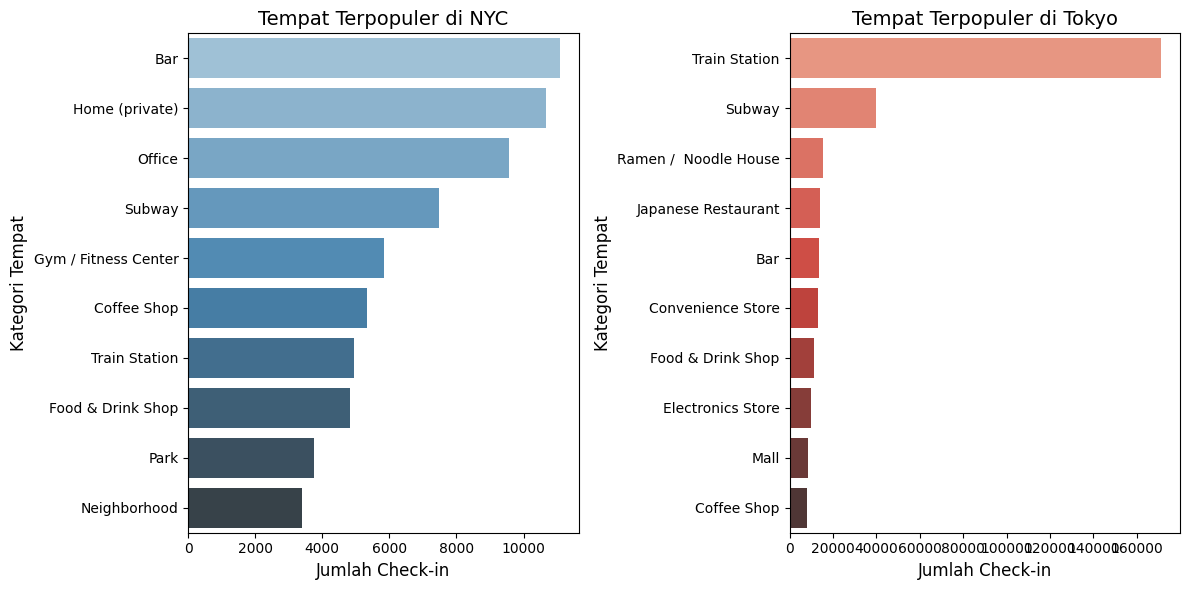

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung frekuensi kategori untuk NYC dan Tokyo
nyc_categories = nyc_data['venueCategory'].value_counts().head(10)
tokyo_categories = tokyo_data['venueCategory'].value_counts().head(10)

# Visualisasi dengan bar chart
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=nyc_categories.values, y=nyc_categories.index, palette="Blues_d")
plt.title("Tempat Terpopuler di NYC", fontsize=14)
plt.xlabel("Jumlah Check-in", fontsize=12)
plt.ylabel("Kategori Tempat", fontsize=12)

plt.subplot(1, 2, 2)
sns.barplot(x=tokyo_categories.values, y=tokyo_categories.index, palette="Reds_d")
plt.title("Tempat Terpopuler di Tokyo", fontsize=14)
plt.xlabel("Jumlah Check-in", fontsize=12)
plt.ylabel("Kategori Tempat", fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import folium
from folium.plugins import HeatMap

# Heatmap untuk NYC
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=12)
HeatMap(data=nyc_data[['latitude', 'longitude']].values, radius=8).add_to(nyc_map)
nyc_map.save("nyc_heatmap.html")  # Simpan sebagai HTML

# Heatmap untuk Tokyo
tokyo_map = folium.Map(location=[35.6895, 139.6917], zoom_start=12)
HeatMap(data=tokyo_data[['latitude', 'longitude']].values, radius=8).add_to(tokyo_map)
tokyo_map.save("tokyo_heatmap.html")  # Simpan sebagai HTML

In [ ]:
from google.colab import files
files.download("nyc_heatmap.html")
files.download("tokyo_heatmap.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Nomor 2

In [ ]:
import pandas as pd

# Konversi kolom waktu ke datetime dengan penanganan kesalahan
def convert_to_datetime(value):
    try:
        return pd.to_datetime(value) # Try to convert using default format
    except (ValueError, TypeError): # Catch parsing errors
        # If fails, attempt converting by format. If failed again, return original value as is
        try:
            return pd.to_datetime(value, format='%a, %d %b %Y %H:%M:%S %Z')
        except ValueError:
            return value

tokyo_data['utcTimestamp'] = tokyo_data['utcTimestamp'].apply(convert_to_datetime)
tokyo_data = tokyo_data[pd.to_datetime(tokyo_data['utcTimestamp'], errors='coerce').notna()]
tokyo_data = tokyo_data.dropna(subset=['utcTimestamp'])

# Tambahkan kolom jam dan hari
tokyo_data['hour'] = tokyo_data['utcTimestamp'].dt.hour
tokyo_data['day_of_week'] = tokyo_data['utcTimestamp'].dt.dayofweek  # 0=Senin, 6=Minggu
tokyo_data['is_weekend'] = tokyo_data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Tampilkan sampel data
print(tokyo_data.head())

<ipython-input-45-e2a5158dd6fd>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tokyo_data['utcTimestamp'] = tokyo_data['utcTimestamp'].apply(convert_to_datetime)


   userId                   venueId           venueCategoryId  \
0    1541  4f0fd5a8e4b03856eeb6c8cb  4bf58dd8d48988d10c951735   
1     868  4b7b884ff964a5207d662fe3  4bf58dd8d48988d1d1941735   
2     114  4c16fdda96040f477cc473a5  4d954b0ea243a5684a65b473   
3     868  4c178638c2dfc928651ea869  4bf58dd8d48988d118951735   
4    1458  4f568309e4b071452e447afe  4f2a210c4b9023bd5841ed28   

           venueCategory   latitude   longitude  timezoneOffset  \
0         Cosmetics Shop  35.705101  139.619590             540   
1  Ramen /  Noodle House  35.715581  139.800317             540   
2      Convenience Store  35.714542  139.480065             540   
3      Food & Drink Shop  35.725592  139.776633             540   
4    Housing Development  35.656083  139.734046             540   

               utcTimestamp  hour  day_of_week  is_weekend  
0 2012-04-03 18:17:18+00:00    18            1           0  
1 2012-04-03 18:22:04+00:00    18            1           0  
2 2012-04-03 19:12:07+0

In [ ]:
import pandas as pd

# Konversi kolom waktu ke datetime dengan penanganan kesalahan
def convert_to_datetime(value):
    try:
        return pd.to_datetime(value) # Try to convert using default format
    except (ValueError, TypeError): # Catch parsing errors
        # If fails, attempt converting by format. If failed again, return original value as is
        try:
            return pd.to_datetime(value, format='%a, %d %b %Y %H:%M:%S %Z')
        except ValueError:
            return value

nyc_data['utcTimestamp'] = nyc_data['utcTimestamp'].apply(convert_to_datetime)
nyc_data = nyc_data[pd.to_datetime(nyc_data['utcTimestamp'], errors='coerce').notna()]
nyc_data = nyc_data.dropna(subset=['utcTimestamp'])


# Tambahkan kolom jam dan hari
nyc_data['hour'] = nyc_data['utcTimestamp'].dt.hour
nyc_data['day_of_week'] = nyc_data['utcTimestamp'].dt.dayofweek  # 0=Senin, 6=Minggu
nyc_data['is_weekend'] = nyc_data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Tampilkan sampel data
print(nyc_data.head())

   userId                   venueId           venueCategoryId  \
0     470  49bbd6c0f964a520f4531fe3  4bf58dd8d48988d127951735   
1     979  4a43c0aef964a520c6a61fe3  4bf58dd8d48988d1df941735   
2      69  4c5cc7b485a1e21e00d35711  4bf58dd8d48988d103941735   
3     395  4bc7086715a7ef3bef9878da  4bf58dd8d48988d104941735   
4      87  4cf2c5321d18a143951b5cec  4bf58dd8d48988d1cb941735   

         venueCategory   latitude  longitude  timezoneOffset  \
0  Arts & Crafts Store  40.719810 -74.002581            -240   
1               Bridge  40.606800 -74.044170            -240   
2       Home (private)  40.716162 -73.883070            -240   
3       Medical Center  40.745164 -73.982519            -240   
4           Food Truck  40.740104 -73.989658            -240   

               utcTimestamp  hour  day_of_week  is_weekend  
0 2012-04-03 18:00:09+00:00    18            1           0  
1 2012-04-03 18:00:25+00:00    18            1           0  
2 2012-04-03 18:02:24+00:00    18        

<ipython-input-46-b5da2929c46c>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nyc_data['utcTimestamp'] = nyc_data['utcTimestamp'].apply(convert_to_datetime)


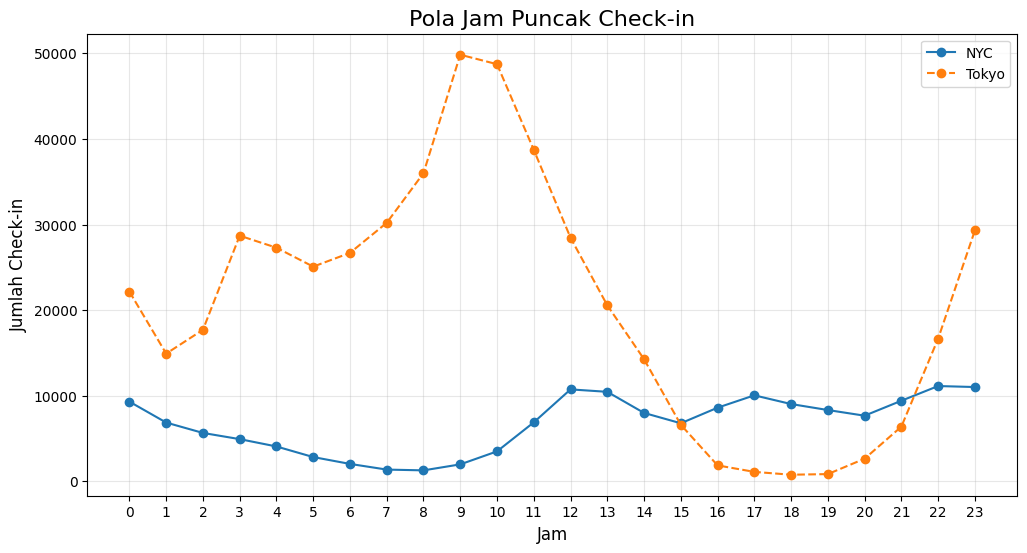

In [ ]:
# Hitung jumlah check-in per jam
nyc_hourly = nyc_data['hour'].value_counts().sort_index()
tokyo_hourly = tokyo_data['hour'].value_counts().sort_index()

# Visualisasi Line Chart
plt.figure(figsize=(12, 6))

plt.plot(nyc_hourly.index, nyc_hourly.values, label="NYC", marker="o", linestyle="-")
plt.plot(tokyo_hourly.index, tokyo_hourly.values, label="Tokyo", marker="o", linestyle="--")

plt.title("Pola Jam Puncak Check-in", fontsize=16)
plt.xlabel("Jam", fontsize=12)
plt.ylabel("Jumlah Check-in", fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

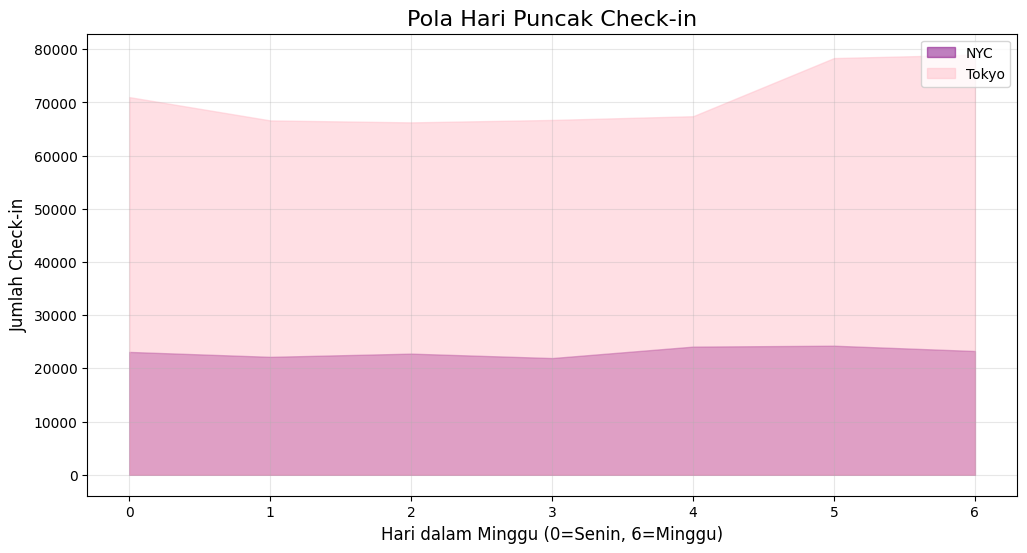

In [ ]:
# Hitung jumlah check-in per hari (weekday vs weekend)
nyc_weekday = nyc_data.groupby('day_of_week')['venueId'].count()
tokyo_weekday = tokyo_data.groupby('day_of_week')['venueId'].count()

# Visualisasi Area Chart
plt.figure(figsize=(12, 6))

plt.fill_between(nyc_weekday.index, nyc_weekday.values, alpha=0.5, label="NYC", color='purple')
plt.fill_between(tokyo_weekday.index, tokyo_weekday.values, alpha=0.5, label="Tokyo", color='pink')

plt.title("Pola Hari Puncak Check-in", fontsize=16)
plt.xlabel("Hari dalam Minggu (0=Senin, 6=Minggu)", fontsize=12)
plt.ylabel("Jumlah Check-in", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
!pip install calmap

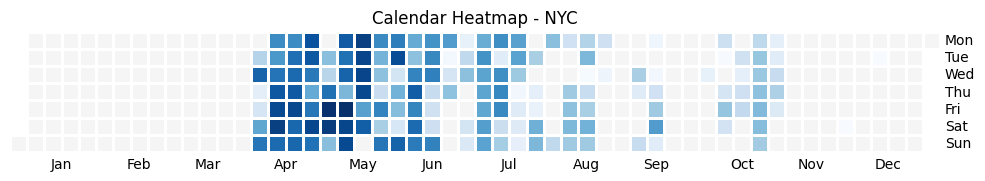

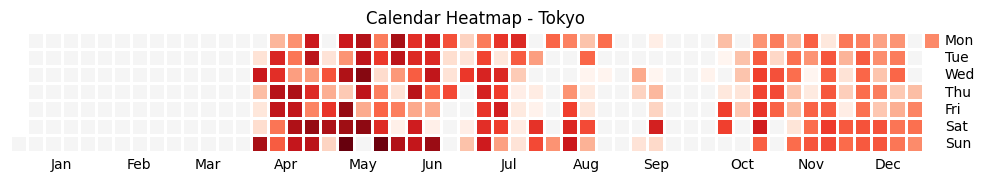

In [ ]:
import calmap
import pandas as pd

# Agregasi check-in berdasarkan tanggal
nyc_daily = nyc_data['utcTimestamp'].dt.date.value_counts().sort_index()
tokyo_daily = tokyo_data['utcTimestamp'].dt.date.value_counts().sort_index()

# Convert the index to datetime objects with year information
nyc_daily.index = pd.to_datetime(nyc_daily.index)
tokyo_daily.index = pd.to_datetime(tokyo_daily.index)

# Extract the year from the first date in the index
year = nyc_daily.index[0].year  # Assumes all data is from the same year

# NYC Calendar Heatmap
plt.figure(figsize=(12, 6))
calmap.yearplot(nyc_daily, year=2012, cmap='Blues')  # Specify the year
plt.title("Calendar Heatmap - NYC")
plt.show()

# Tokyo Calendar Heatmap
plt.figure(figsize=(12, 6))
calmap.yearplot(tokyo_daily, year=2012, cmap='Reds')  # Specify the year
plt.title("Calendar Heatmap - Tokyo")
plt.show()